In [10]:
!pip install networkx
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
np.random.seed(42)
N = 100          # number of agents
T = 50           # number of time steps
mu = 0.2         # influence strength
epsilon = 0.4    # bounded confidence threshold
beta = 4.0       # recommender similarity bias

## Initial Conditions

In [2]:
#discrete opinions
def initialize_discrete_opinions(N, p_positive=0.5):
    """
    Creates binary opinions in {-1, +1}.
    p_positive controls the proportion of +1 opinions.
    """
    return np.random.choice([-1, 1], size=N, p=[1 - p_positive, p_positive])

#continuous opinions
def initialize_continuous_opinions(N, distribution="uniform"):
    """
    Creates continuous opinions in [-1, 1].
    """
    if distribution == "uniform":
        return np.random.uniform(-1, 1, N)

    elif distribution == "normal":
        opinions = np.random.normal(0, 0.35, N)
        return np.clip(opinions, -1, 1)

    elif distribution == "bimodal":
        group1 = np.random.normal(-0.5, 0.2, N // 2)
        group2 = np.random.normal(0.5, 0.2, N - N // 2)
        opinions = np.concatenate([group1, group2])
        return np.clip(opinions, -1, 1)

    else:
        raise ValueError("distribution must be 'uniform', 'normal', or 'bimodal'")

## Graph generation

In [3]:
def create_graph(N, p=0.08):
    """ undirected Erdos-Renyi graph.
    p controls the probability of edge between two nodes.
    """
    G = nx.erdos_renyi_graph(N, p, seed=42)

    # Make sure the graph is connected.
    # If not connected, take the largest connected component or regenerate.
    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(N, p, seed=np.random.randint(10000))

    return G

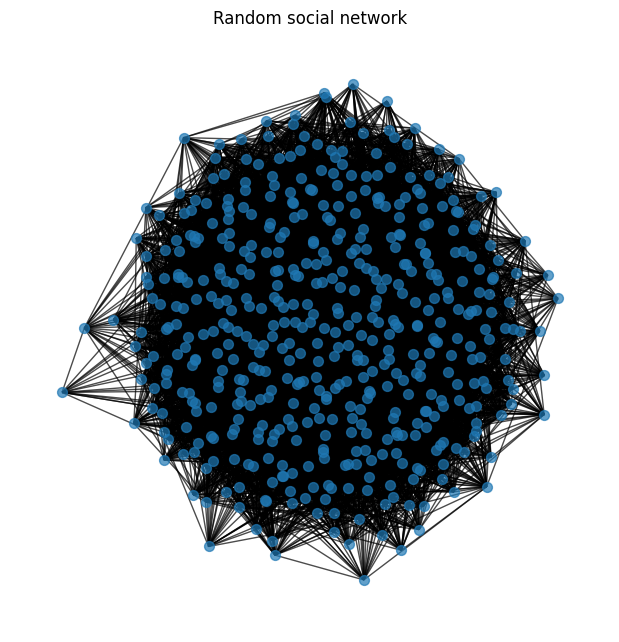

In [4]:
# ex instantiation
G = create_graph(N, p=0.08)
plt.figure(figsize=(6, 6))
nx.draw(G, node_size=50, alpha=0.7)
plt.title("Random social network")
plt.show()

## Model 1 (discrete, non graph)


In [5]:
def run_discrete_mean_field(s0, T):
    """
    Discrete non-graph model.
    Each agent samples their next opinion from the global population distribution.
    """
    N = len(s0)
    history = np.zeros((T + 1, N))
    history[0] = s0.copy()

    s = s0.copy()

    for t in range(T):
        p_positive = np.mean(s == 1)

        # Each agent becomes +1 with probability p_positive.
        s = np.random.choice([-1, 1], size=N, p=[1 - p_positive, p_positive])

        history[t + 1] = s.copy()

    return history

## Model 2: discrete, graph

local social copying, agents interact only with network neighbors


In [6]:
def run_discrete_voter_graph(G, s0, T):
    """
    discrete graph-based voter model.
    Each node copies opinion of randomly selected neighbor.
    """
    N = len(s0)
    history = np.zeros((T + 1, N))
    history[0] = s0.copy()

    s = s0.copy()

    for t in range(T):
        new_s = s.copy()

        for i in range(N):
            neighbors = list(G.neighbors(i))

            if len(neighbors) > 0:
                chosen_neighbor = np.random.choice(neighbors)
                new_s[i] = s[chosen_neighbor]

        s = new_s
        history[t + 1] = s.copy()

    return history

## Model 3: continous, non-graph

options are continous, gradual opinion adjustment

In [29]:
def run_continuous_mean_field(s0, T, mu=0.2):
    """
    Continuous non-graph model.
    Each agent moves toward the population mean.
    """
    N = len(s0)
    history = np.zeros((T + 1, N))
    history[0] = s0.copy()

    s = s0.copy()

    for t in range(T):
        mean_opinion = np.mean(s)

        s = s + mu * (mean_opinion - s)

        # Keep opinions inside [-1, 1].
        s = np.clip(s, -1, 1)

        history[t + 1] = s.copy()

    return history

## Model 4: continuous, graph based

In [38]:
def run_recommender_weighted_graph(G, s0, T, mu=0.2, epsilon=0.4, beta=4.0):
    """
    Continuous graph-based recommender-weighted bounded confidence model.

    Agents are influenced by neighbors.
    Similar neighbors receive higher recommender weights.
    Influence only occurs if opinions are within epsilon.
    """
    N = len(s0)
    history = np.zeros((T + 1, N))
    history[0] = s0.copy()

    s = s0.copy()

    for t in range(T):
        new_s = s.copy()

        for i in range(N):
            neighbors = list(G.neighbors(i))

            if len(neighbors) == 0:
                continue

            # Opinion distances between i and its neighbors
            distances = np.array([abs(s[i] - s[j]) for j in neighbors])

            # Recommender weights favor similar opinions
            weights = np.exp(-beta * distances)

            # Normalize weights into probabilities
            probabilities = weights / np.sum(weights)

            # Bounded confidence mask
            confidence_mask = distances <= epsilon

            if np.any(confidence_mask):
                influence = 0

                for idx, j in enumerate(neighbors):
                    if confidence_mask[idx]:
                        influence += probabilities[idx] * (s[j] - s[i])

                new_s[i] = s[i] + mu * influence

        s = np.clip(new_s, -1, 1)
        history[t + 1] = s.copy()

    return history

## Run all models, same initial conditions

In [47]:
# Initial states
s0_discrete = initialize_discrete_opinions(N, p_positive=0.5)
s0_continuous = initialize_continuous_opinions(N, distribution="bimodal")

# Graph
G = create_graph(N, p=0.08)

# Run models
hist_discrete_mean = run_discrete_mean_field(s0_discrete, T)
hist_discrete_graph = run_discrete_voter_graph(G, s0_discrete, T)

hist_continuous_mean = run_continuous_mean_field(s0_continuous, T, mu=mu)
hist_recommender_graph = run_recommender_weighted_graph(
    G,
    s0_continuous,
    T,
    mu=mu,
    epsilon=epsilon,
    beta=beta
)

## Metrics

In [48]:
def mean_opinion(history):
    return np.mean(history, axis=1)

def opinion_variance(history):
    return np.var(history, axis=1)

def final_std(history):
    return np.std(history[-1])

def reached_discrete_consensus(history):
    final = history[-1]
    return np.all(final == final[0])

def reached_continuous_consensus(history, threshold=0.01):
    return np.var(history[-1]) < threshold

In [49]:
def plot_mean_opinion(histories, labels):
    plt.figure(figsize=(8, 5))

    for history, label in zip(histories, labels):
        plt.plot(mean_opinion(history), label=label)

    plt.xlabel("Time step")
    plt.ylabel("Mean opinion")
    plt.title("Mean opinion over time")
    plt.legend()
    plt.grid(True)
    plt.show()

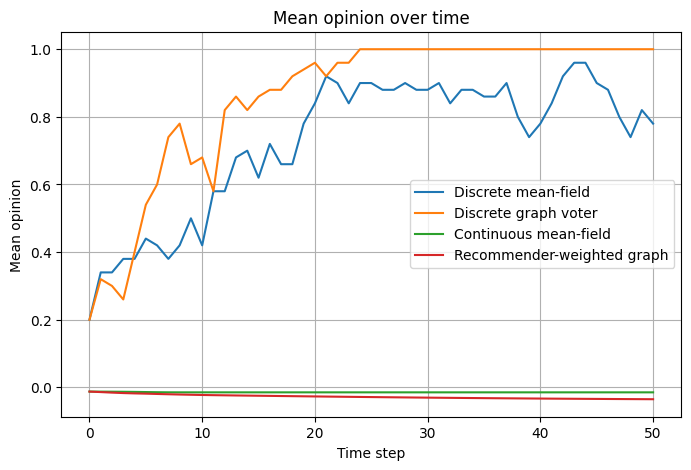

In [50]:
plot_mean_opinion(
    [
        hist_discrete_mean,
        hist_discrete_graph,
        hist_continuous_mean,
        hist_recommender_graph
    ],
    [
        "Discrete mean-field",
        "Discrete graph voter",
        "Continuous mean-field",
        "Recommender-weighted graph"
    ]
)

In [28]:
#polarization over time
def plot_variance(histories, labels):
    plt.figure(figsize=(8, 5))

    for history, label in zip(histories, labels):
        plt.plot(opinion_variance(history), label=label)

    plt.xlabel("Time step")
    plt.ylabel("Opinion variance")
    plt.title("Polarization over time")
    plt.legend()
    plt.grid(True)
    plt.show()

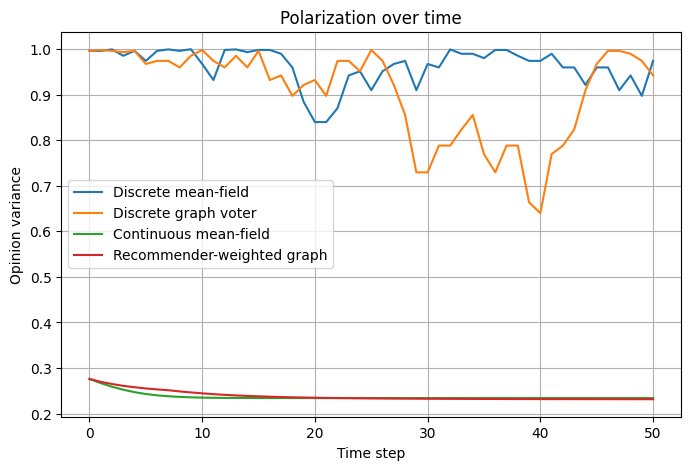

In [37]:
plot_variance(
    [
        hist_discrete_mean,
        hist_discrete_graph,
        hist_continuous_mean,
        hist_recommender_graph
    ],
    [
        "Discrete mean-field",
        "Discrete graph voter",
        "Continuous mean-field",
        "Recommender-weighted graph"
    ]
)

In [44]:
#final opinion distributions
def plot_final_distribution(history, title):
    plt.figure(figsize=(7, 4))
    plt.hist(history[-1], bins=20, edgecolor="black")
    plt.xlabel("Opinion")
    plt.ylabel("Number of agents")
    plt.title(title)
    plt.grid(True)
    plt.show()

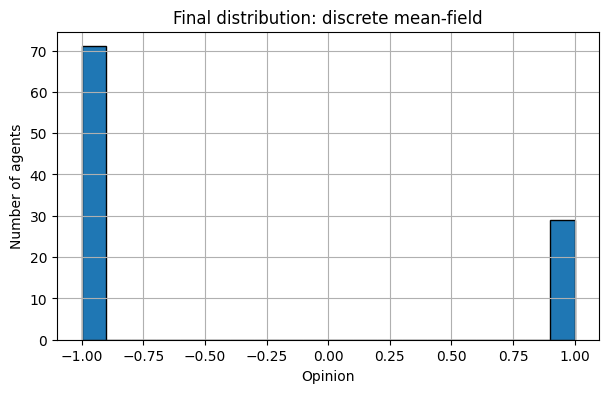

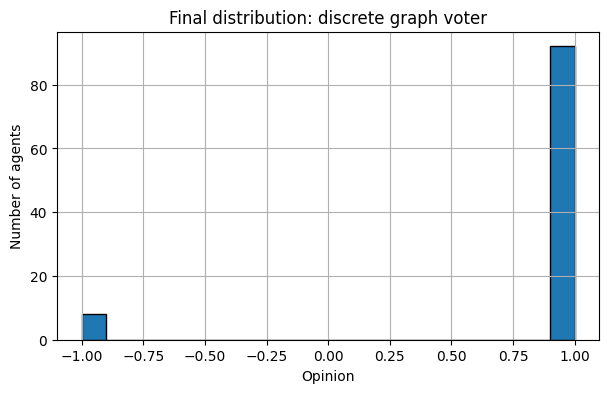

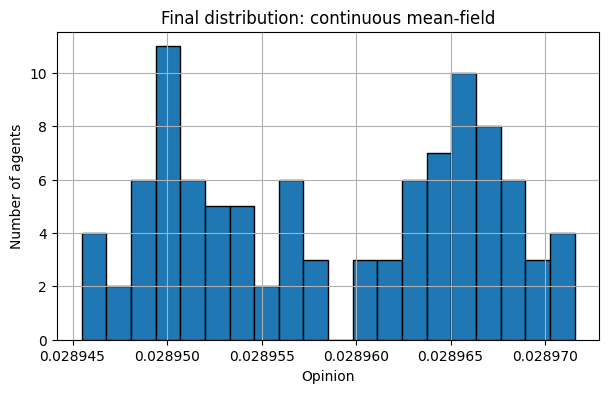

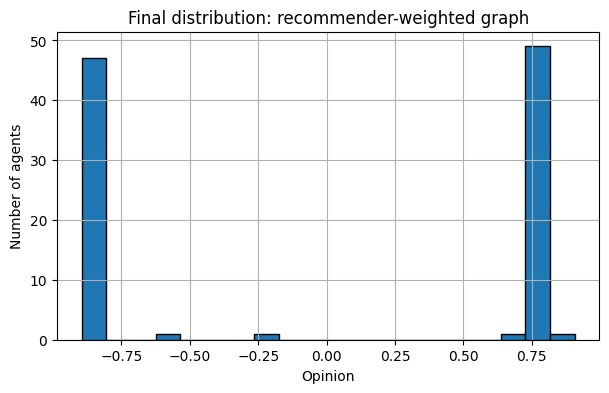

In [45]:
plot_final_distribution(hist_discrete_mean, "Final distribution: discrete mean-field")
plot_final_distribution(hist_discrete_graph, "Final distribution: discrete graph voter")
plot_final_distribution(hist_continuous_mean, "Final distribution: continuous mean-field")
plot_final_distribution(hist_recommender_graph, "Final distribution: recommender-weighted graph")

In [21]:
def summarize_model(history, model_name, model_type):
    return {
        "model": model_name,
        "type": model_type,
        "final_mean": np.mean(history[-1]),
        "final_variance": np.var(history[-1]),
        "final_std": np.std(history[-1]),
        "min_opinion": np.min(history[-1]),
        "max_opinion": np.max(history[-1])
    }

In [22]:
results = [
    summarize_model(hist_discrete_mean, "Discrete mean-field", "non-graph, discrete"),
    summarize_model(hist_discrete_graph, "Discrete graph voter", "graph, discrete"),
    summarize_model(hist_continuous_mean, "Continuous mean-field", "non-graph, continuous"),
    summarize_model(hist_recommender_graph, "Recommender-weighted graph", "graph, continuous")
]

for r in results:
    print(r)

{'model': 'Discrete mean-field', 'type': 'non-graph, discrete', 'final_mean': np.float64(0.36), 'final_variance': np.float64(0.8703999999999996), 'final_std': np.float64(0.9329523031752479), 'min_opinion': np.float64(-1.0), 'max_opinion': np.float64(1.0)}
{'model': 'Discrete graph voter', 'type': 'graph, discrete', 'final_mean': np.float64(-0.02), 'final_variance': np.float64(0.9996), 'final_std': np.float64(0.999799979995999), 'min_opinion': np.float64(-1.0), 'max_opinion': np.float64(1.0)}
{'model': 'Continuous mean-field', 'type': 'non-graph, continuous', 'final_mean': np.float64(-0.0002160720334714316), 'final_variance': np.float64(5.682351012339109e-11), 'final_std': np.float64(7.538137045941198e-06), 'min_opinion': np.float64(-0.00022887869434676548), 'max_opinion': np.float64(-0.00020351832430872205)}
{'model': 'Recommender-weighted graph', 'type': 'graph, continuous', 'final_mean': np.float64(-0.010297940867474304), 'final_variance': np.float64(0.23187478130141465), 'final_std'

In [24]:
!pip install pandas
import pandas as pd

results_df = pd.DataFrame(results)
results_df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 8.8 MB/s  0:00:01eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]


,model,type,final_mean,final_variance,final_std,min_opinion,max_opinion
0,Discrete mean-field,"non-graph, discrete",0.360000,8.704000e-01,0.932952,-1.000000,1.000000
1,Discrete graph voter,"graph, discrete",-0.020000,9.996000e-01,0.999800,-1.000000,1.000000
2,Continuous mean-field,"non-graph, continuous",-0.000216,5.682351e-11,0.000008,-0.000229,-0.000204
3,Recommender-weighted graph,"graph, continuous",-0.010298,2.318748e-01,0.481534,-0.560760,0.489985


## Testing across recommonder bias

In [25]:
beta_values = [0.0, 1.0, 3.0, 6.0, 10.0]

beta_histories = {}

for b in beta_values:
    beta_histories[b] = run_recommender_weighted_graph(
        G,
        s0_continuous,
        T,
        mu=mu,
        epsilon=epsilon,
        beta=b
    )

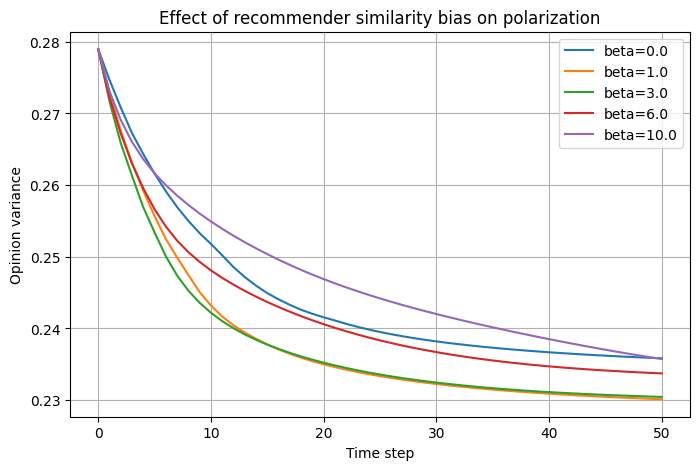

In [26]:
plt.figure(figsize=(8, 5))

for b, history in beta_histories.items():
    plt.plot(opinion_variance(history), label=f"beta={b}")

plt.xlabel("Time step")
plt.ylabel("Opinion variance")
plt.title("Effect of recommender similarity bias on polarization")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
distributions = ["uniform", "normal", "bimodal"]

distribution_histories = {}

for dist in distributions:
    s0 = initialize_continuous_opinions(N, distribution=dist)

    distribution_histories[dist] = run_recommender_weighted_graph(
        G,
        s0,
        T,
        mu=mu,
        epsilon=epsilon,
        beta=beta
    )